# Data Pipelines & Data Analytics Lifecycle
# Forecasting the Wind Power Production in Orkney

## Introduction

In this assignment you will play the role of a Data Scientist consultant for the Scottish and Southern Electricity Networks (SSEN). Among many other areas, the SSEN provides electricity for the Okrney islands, in Northern Scottland. This archipelago has significant wind and marine energy resources, and it generates over 100% of its 
net power from renewable sources, coming mainly from wind turbines situated across Orkney. This is good news for Orkney and the environment, but although wind farms provide emissions-free energy, they only generate electricity when the wind blows.

Your job? To design and implement a training pipeline, including data preprocessing, evaluation and model storing, for a small wind energy forecasting system. The goal here is to use weather forecasting data to predict the energy production for Orkney. You will need all your data scientist skills for insights, and you will have 
some libraries at your disposal, such as Scikit-Learn and MLFlow (and as many others as you might need). This Jupyter Notebook will help you started.

The steps you will complete in this project are:

- align the datasets
- create pipelines for preprocessing and prediction
- compare your pipelines with MLflow Tracking
- register your best model with MLflow Registry
- serve the best model
- package the project using MLProjects

Above this cell you will find an *Outline* button. Click it and an outline of this notebook should appear on the left bottom corner of the screen. This will help you navigate to a specific section.

**Dependencies**

If you've just created this workspace, install mlflow by typing the command below in the Terminal. If you already did this in a previous session, there is no need to install it again.

```
pip install mlflow
```

Now let's import all libraries necessary for this project.
The first time you will run a cell in this notebook, a dialogue box will appear asking if you want to Install/enable suggested extentions: python and jupyter. Go ahead and once that is finished select the created kernel.

In [2]:
import mlflow

# You will probably need these
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline

# This are for example purposes. You may discard them if you don't use them.
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from mlflow.models import infer_signature
from urllib.parse import urlparse

### TODO -> HERE YOU CAN ADD ANY OTHER LIBRARIES YOU MAY NEED ###

<a name="data"></a> 

## Data exploration

You will work with three datasets:

**Power generation data** (`power.csv`)

* *Source:* Scottish and Southern Electricity Networks (SSEN)
* *Granularity:* 1-minute sampling
* *Target variable:* Total renewable power generation (MW)

Key fields:

* `time`: Timestamp of measurement
* `Total`: Renewable power generation (MW)

**Weather forecast data** (`weather.csv`)

* *Source:* UK Met Office
* *Granularity:* 3-hour intervals
* Forecasts include a *source time* (forecast creation) and a *target time* (forecasted timestamp)

Key fields:

* `time`: Target time of the forecast
* `Speed`: Wind speed (m/s)
* `Direction`: Wind direction (categorical string, e.g. "NW")
* `Source_time`: Forecast generation time
* `Lead_hours`: Forecast horizon

**Future forecasts** (`future.csv`)

* Weather forecasts to be used for generating future power predictions using your model

Let's first load the first 2 datasets.

In [3]:
power_df = pd.read_csv('data/power.csv', parse_dates=["time"])
wind_df = pd.read_csv('data/weather.csv', parse_dates=["time"])

Let's take a look at the resulting dataframes:

In [4]:
power_df.head()

,time,ANM,Non-ANM,Total
0,2021-12-11 13:39:00+00:00,10.195558,17.102,27.297558
1,2021-12-11 13:40:00+00:00,10.043559,17.582,27.625559
2,2021-12-11 13:41:00+00:00,10.961558,17.139,28.100558
3,2021-12-11 13:42:00+00:00,11.240559,16.194,27.434559
4,2021-12-11 13:43:00+00:00,10.672559,16.566,27.238559


This table contains three columns, but closer inspection will reveal a clear relationship between those three. Can you spot that? **>>> 'ANM' + 'Non-ANM' = 'Total', so we can keep the latter and remove the other two columns.**

We are interested in the total power generation, regardless of the source type. Modify the table such that only the column of interest is kept.

Fraction of cases in which 'Total power' matches 'ANM power' + 'Non-ANM power' (3 decimal digits):  1.0


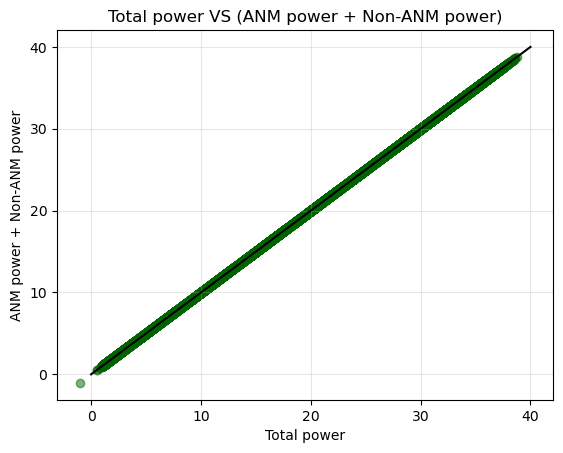

In [5]:
### TODO -> REMOVE UNNECESSARY COLUMNS ###

amt = np.sum(round(power_df['ANM']+power_df['Non-ANM'], 3) == round(power_df['Total'], 3))
print("Fraction of cases in which 'Total power' matches 'ANM power' + 'Non-ANM power' (3 decimal digits): ", round(amt / len(power_df), 3))

plt.grid(alpha= 0.3)
plt.scatter(power_df['Total'], power_df['ANM']+power_df['Non-ANM'], c= 'darkgreen', alpha= 0.5)
plt.plot([0, 40], [0, 40], c= 'black')

plt.title("Total power VS (ANM power + Non-ANM power)")
plt.xlabel("Total power")
plt.ylabel("ANM power + Non-ANM power")
plt.show()

In [6]:
power_df.drop(['ANM', 'Non-ANM'], axis= 1, inplace= True)

In [7]:
wind_df.head()
power_df['change'] = power_df['Total'].diff()
print(power_df)
print(power_df['Total'].var())

                            time      Total    change
0      2021-12-11 13:39:00+00:00  27.297558       NaN
1      2021-12-11 13:40:00+00:00  27.625559  0.328001
2      2021-12-11 13:41:00+00:00  28.100558  0.474999
3      2021-12-11 13:42:00+00:00  27.434559 -0.665999
4      2021-12-11 13:43:00+00:00  27.238559 -0.196000
...                          ...        ...       ...
109021 2022-03-11 13:34:00+00:00  33.405000 -0.090002
109022 2022-03-11 13:35:00+00:00  33.418000  0.013000
109023 2022-03-11 13:36:00+00:00  33.305998 -0.112002
109024 2022-03-11 13:37:00+00:00  33.184999 -0.120999
109025 2022-03-11 13:38:00+00:00  33.292000  0.107001

[109026 rows x 3 columns]
124.27987881242156


This table contains four columns, but lead hours and source time are irrelevant here. Can you think why? **>>> 'Lead_hours' only contains a constant value, while 'Source_time'.** 

is included in the regular time

It also contains a column named Direction, which shows the cardinal direction that the wind is blowing from. For example, the record containing ’SW’ in the wind direction field would indicate that the wind is blowing from the South-West (and to
the North-East). Since our models can only handle numeric data, you will need to perform some transformation on this feature later on.

Look at the table's index. Do both data sources contain the same intervals? And if not, what problems could arise when merging the data? **>>> while the power dataset records data every minute, the wind dataset contains one entry per 3 hours. For each datapoint in the latter, we have 180 in the former. A simple merge would result in a huge amount of missing values.**

In [8]:
wind_df['Lead_hours'].unique()

array([1])

In [9]:
wind_df.drop(['Lead_hours', 'Source_time'], axis= 1, inplace= True)

In [10]:
# convert cardinal direction into corresponding degree (assuming North is at deg= 0) 

print(wind_df['Direction'].unique())

class WindDirectionEncoder():

    def __init__(self):
        self.deg_conversion_ = {
            'N' : 0,
            'NNE' : 22.5,
            'NE' : 45,
            'ENE' : 67.5,
            'E' : 90,
            'ESE' : 112.5,
            'SE' : 135,
            'SSE' : 157.5,
            'S' : 180,
            'SSW' : 202.5,
            'SW' : 225,
            'WSW' : 247.5,
            'W' : 270,
            'WNW' : 292.5,
            'NW' : 315,
            'NNW' : 337.5
        }

    # no fitting needed, just to align with sklearn
    def fit(self, X= None, y=None):
        return self

    # apply transformation
    def transform(self, X: np.ndarray | pd.DataFrame, y=None):
        
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()

        X[:, 1] = pd.Series(X[:, 1]).map(self.deg_conversion_).to_numpy()
        return X

deg_conversion = {
    'N' : 0,
    'NNE' : 22.5,
    'NE' : 45,
    'ENE' : 67.5,
    'E' : 90,
    'ESE' : 112.5,
    'SE' : 135,
    'SSE' : 157.5,
    'S' : 180,
    'SSW' : 202.5,
    'SW' : 225,
    'WSW' : 247.5,
    'W' : 270,
    'WNW' : 292.5,
    'NW' : 315,
    'NNW' : 337.5
}

['SSE' 'SSW' 'WSW' 'SW' 'S' 'SE' 'W' 'WNW' 'NW' 'NNW' 'NNE' 'NE' 'ENE' 'E'
 'ESE' 'N']


In [ ]:
pd.DataFrame(WindDirectionEncoder().transform(wind_df))

,0,1,2
0,2021-12-11 15:00:00+00:00,157.5,11.176
1,2021-12-11 18:00:00+00:00,202.5,8.04672
2,2021-12-11 21:00:00+00:00,247.5,11.176
3,2021-12-12 00:00:00+00:00,247.5,8.9408
4,2021-12-12 03:00:00+00:00,225.0,9.83488
...,...,...,...
711,2022-03-10 21:00:00+00:00,180.0,9.83488
712,2022-03-11 00:00:00+00:00,157.5,11.176
713,2022-03-11 03:00:00+00:00,157.5,9.83488
714,2022-03-11 06:00:00+00:00,157.5,8.9408


In [13]:
wind_df['Direction_Degree'] = wind_df.apply(lambda row: deg_conversion[row['Direction']], axis= 1)
wind_df

,time,Direction,Speed,Direction_Degree
0,2021-12-11 15:00:00+00:00,SSE,11.17600,157.5
1,2021-12-11 18:00:00+00:00,SSW,8.04672,202.5
2,2021-12-11 21:00:00+00:00,WSW,11.17600,247.5
3,2021-12-12 00:00:00+00:00,WSW,8.94080,247.5
4,2021-12-12 03:00:00+00:00,SW,9.83488,225.0
...,...,...,...,...
711,2022-03-10 21:00:00+00:00,S,9.83488,180.0
712,2022-03-11 00:00:00+00:00,SSE,11.17600,157.5
713,2022-03-11 03:00:00+00:00,SSE,9.83488,157.5
714,2022-03-11 06:00:00+00:00,SSE,8.94080,157.5


### Data alignment
We have two dataframes, one with weather forecasts and one with power generation. To do some analysis on the relationship between these two datasets, it might be useful to align the datasets.

**Example**

In [14]:
# Joining the data
joined_dfs = power_df.merge(wind_df, how="inner", on= 'time')
is_sorted = power_df['time'].is_monotonic_increasing
print(is_sorted)
is_sorted2 = wind_df['time'].is_monotonic_increasing
print(is_sorted2)


True
True


Joining the two datasets with an inner join means keeping only those records that match their index. Although this will work, you may notice that most of our data is discarded due to the unmatching time intervals. You may want to explore other possible ways to merge the data; you can argue for using a specific method or experiment with both later on. For now, try out a different way to align the datasets.

In [15]:
### TODO -> JOIN THE TWO DATASETS ###

# merge_asof assigns each power record the most recent wind forecast available at that time,
# preserving all power readings instead of discarding non-matching timestamps.

power_3h = power_df.set_index('time').resample('3h').mean().reset_index()
joined_dfs = pd.merge_asof(power_3h, wind_df, on='time', direction='backward', tolerance=pd.Timedelta('3h')).dropna()

joined_dfs.shape


(678, 6)

In [16]:
std_list = np.array([])

for i in range(len(wind_df)-1):

    start = wind_df['time'].loc[i]
    end = wind_df['time'].loc[i+1]
    subset = power_df[(power_df['time'] > start) & (power_df['time'] <= end)]['Total']
    
    mean = subset.mean()
    std = subset.std()
    std_list = np.append(std_list, std)
    # print(f"Total power for subset from {start} to {end}: mean= {mean:.3f} +/- {std:.3f}")

avg_std = std_list[~np.isnan(std_list)].mean()
avg_total_power = power_df['Total'].mean()
perc = avg_std / avg_total_power

print(f"Average standard deviation from mean for subset: {avg_std:.3f} ({perc:.3%} of average total power output)")

Average standard deviation from mean for subset: 1.851 (8.436% of average total power output)


### Understanding the data: EDA

It can be also useful to plot our datasets to see what relationships they might hold.

C:\Users\User\AppData\Local\Temp\ipykernel_26416\277275091.py:17: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_7_days = plot_df.last('7D') # Or use plot_df.loc[plot_df.index.max() - pd.Timedelta(days=7):]


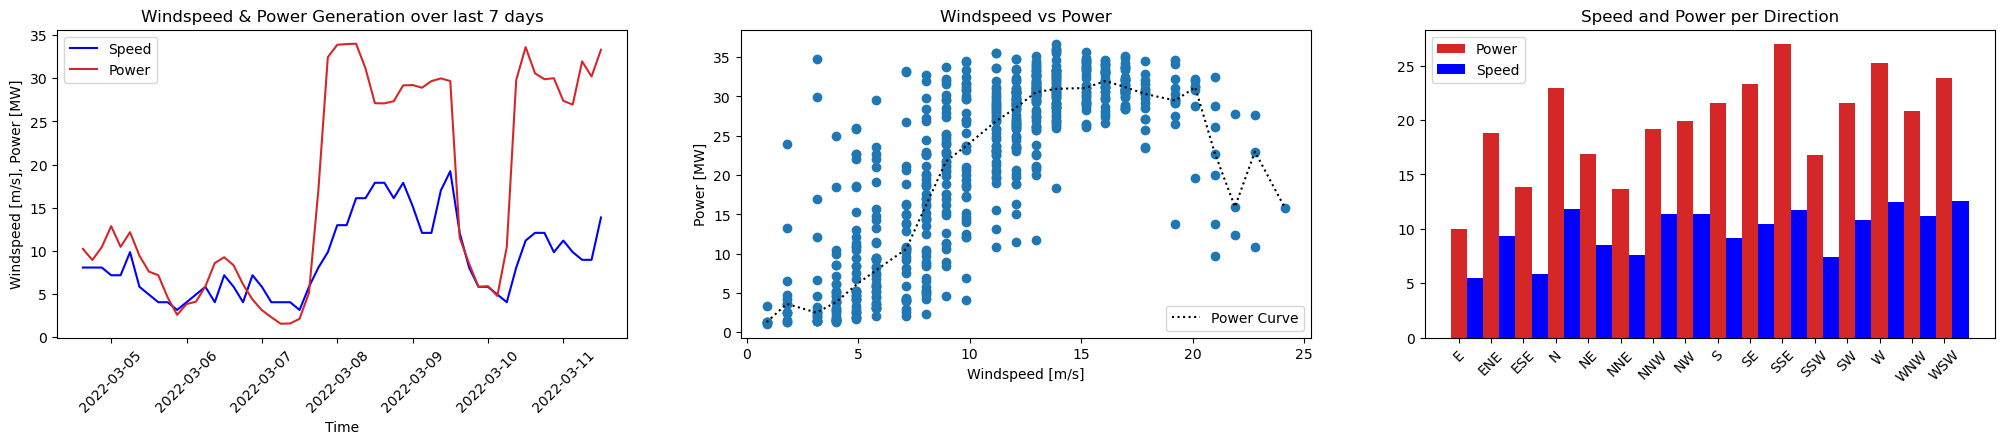

In [17]:
# Subplots
# fig, ax = plt.subplots(1,3, figsize=(25,4))

# # Speed and Power for the last 7 days
# ax[0].plot(joined_dfs["Speed"].tail(int(7*24/3)), label="Speed", color="blue") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
# ax[0].plot(joined_dfs["Total"].tail(int(7*24/3)), label="Power", color="tab:red") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
# ax[0].set_title("Windspeed & Power Generation over last 7 days")
# ax[0].set_xlabel("Time")
# ax[0].tick_params(axis='x', labelrotation = 45)
# ax[0].set_ylabel("Windspeed [m/s], Power [MW]")
# ax[0].legend()

# Temporary or permanent index setting for easy slicing
plot_df = joined_dfs.set_index('time')

# Slice exactly the last 7 days
last_7_days = plot_df.last('7D') # Or use plot_df.loc[plot_df.index.max() - pd.Timedelta(days=7):]

# Subplots
fig, ax = plt.subplots(1,3, figsize=(25,4))

# Plot using the sliced dataframe
ax[0].plot(last_7_days.index, last_7_days["Speed"], label="Speed", color="blue")
ax[0].plot(last_7_days.index, last_7_days["Total"], label="Power", color="tab:red")
ax[0].set_title("Windspeed & Power Generation over last 7 days")
ax[0].set_xlabel("Time")
ax[0].tick_params(axis='x', labelrotation = 45)
ax[0].set_ylabel("Windspeed [m/s], Power [MW]")
ax[0].legend()

# Speed vs Total (Power Curve nature)
ax[1].scatter(joined_dfs["Speed"], joined_dfs["Total"])
power_curve = joined_dfs.groupby("Speed").median(numeric_only=True)["Total"]
ax[1].plot(power_curve.index, power_curve.values, "k:", label="Power Curve")
ax[1].legend()
ax[1].set_title("Windspeed vs Power")
ax[1].set_ylabel("Power [MW]")
ax[1].set_xlabel("Windspeed [m/s]")

# Speed and Power per Wind Direction
wind_grouped_by_direction = joined_dfs.groupby("Direction").mean(numeric_only=True).reset_index()
bar_width = 0.5
x = np.arange(len(wind_grouped_by_direction.index))

ax[2].bar(x, wind_grouped_by_direction.Total, width=0.5, label="Power", color="tab:red")
ax[2].bar(x + bar_width, wind_grouped_by_direction.Speed, width=0.5, label="Speed", color="blue")
ax[2].legend()
ax[2].set_xticks(x)
ax[2].set_xticklabels(wind_grouped_by_direction.Direction)
ax[2].tick_params(axis='x', labelrotation = 45)
ax[2].set_title("Speed and Power per Direction");

These plots should already give us an intuition of the different relationships between features. There is a clear relationship between the wind speed and the power generation from the turbines. But that relationship is not completely linear. Which plot shows that? Finally, it seems like the power generation also depends of where the wind is coming from. Maybe this could also be a useful feature.

In order to plot the relationship between wind speed and power generation we have performed a very simple join with the two datasets. But since the intervals are not the same, a lot of data is discarded (can you spot where in the code this happens?). 

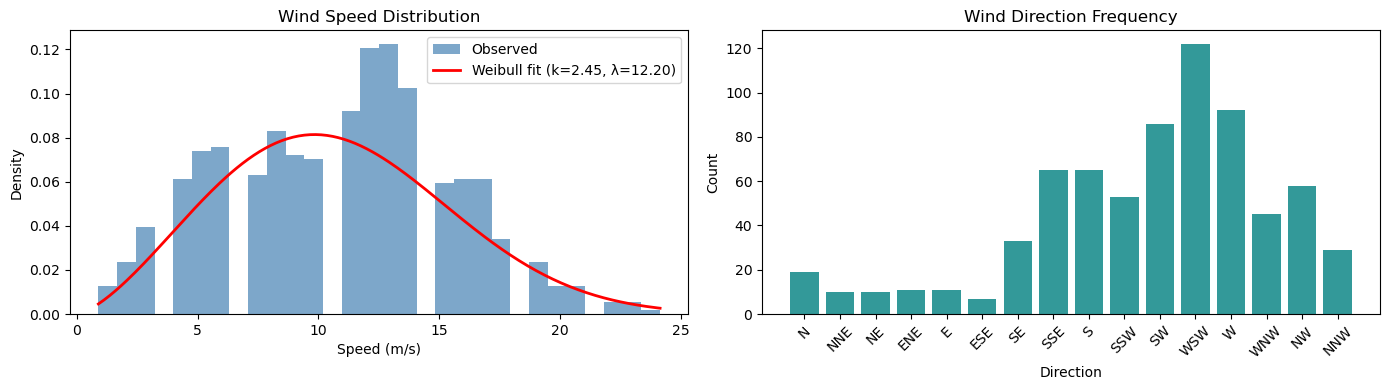

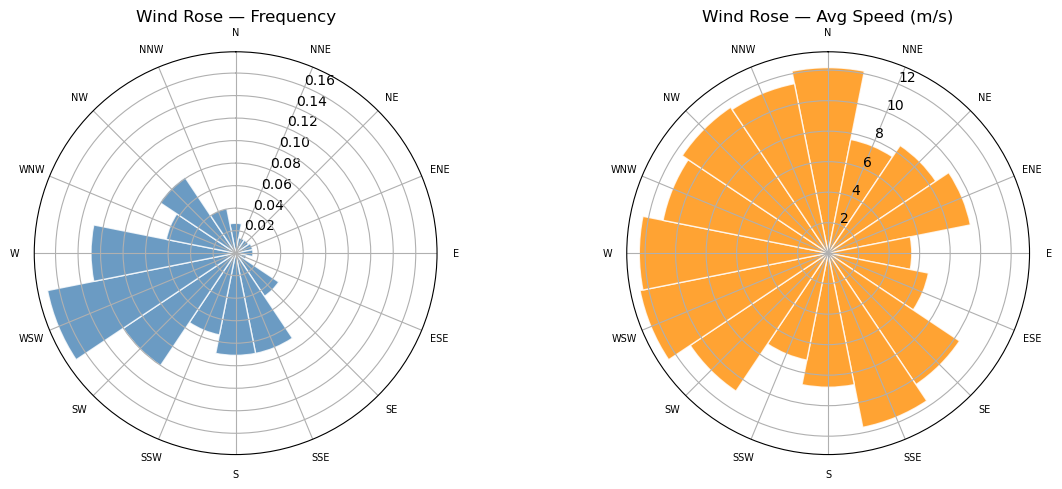

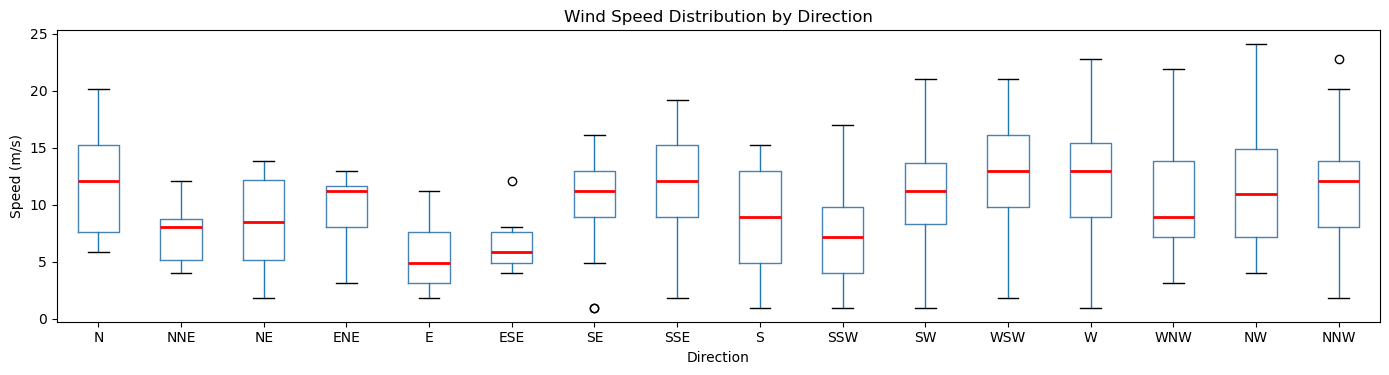

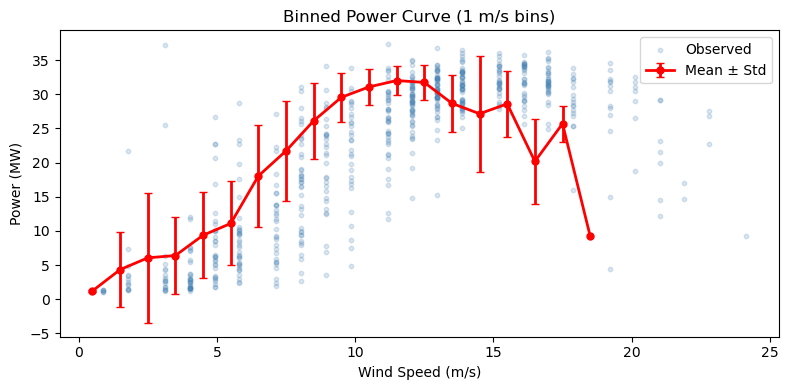

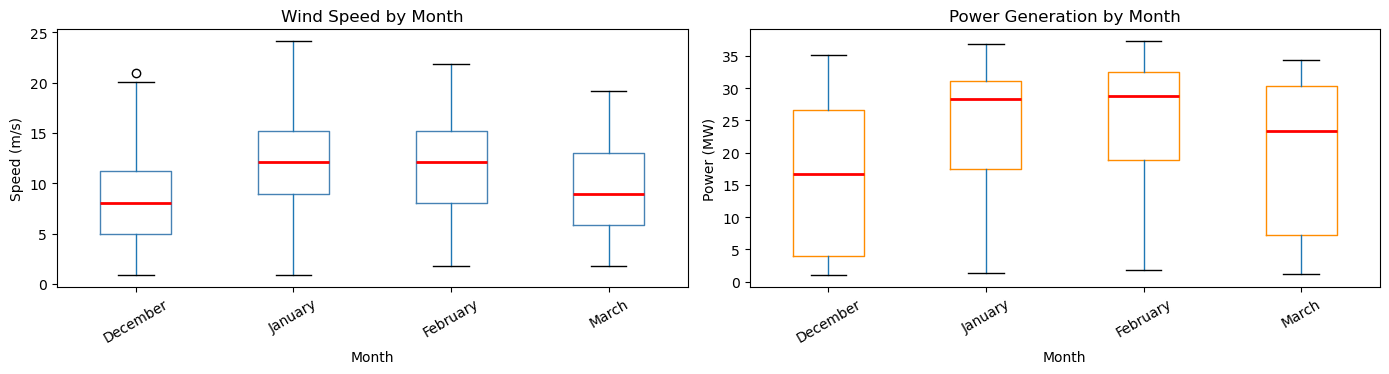

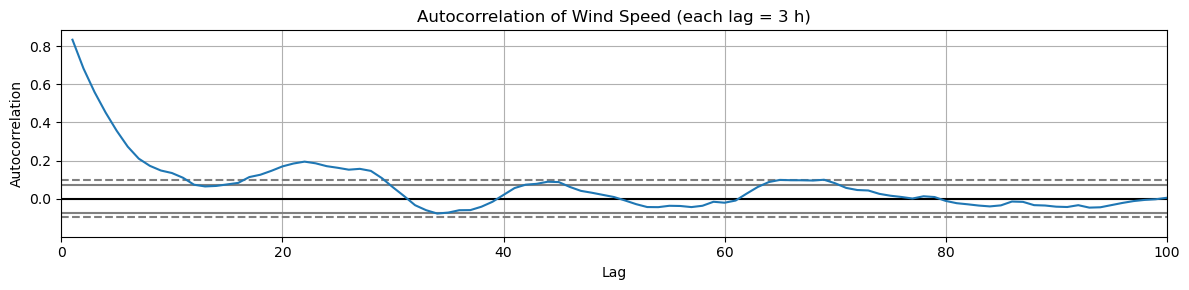

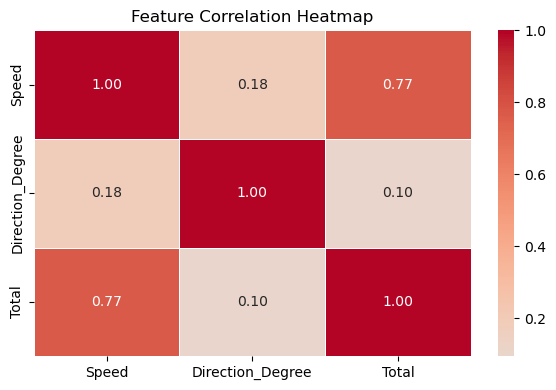

In [18]:
### TODO -> DO SOME EXTRA EDA ON THE DATA ###

from scipy.stats import weibull_min
from pandas.plotting import autocorrelation_plot
from matplotlib.gridspec import GridSpec

joined = power_df.merge(wind_df, on='time').dropna()

# ── 1. Wind Speed Distribution + Weibull Fit ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

speeds = wind_df['Speed'].dropna()
axes[0].hist(speeds, bins=30, density=True, color='steelblue', alpha=0.7, label='Observed')
shape, loc, scale = weibull_min.fit(speeds, floc=0)
x = np.linspace(speeds.min(), speeds.max(), 200)
axes[0].plot(x, weibull_min.pdf(x, shape, loc, scale), 'r-', lw=2,
             label=f'Weibull fit (k={shape:.2f}, λ={scale:.2f})')
axes[0].set_title('Wind Speed Distribution')
axes[0].set_xlabel('Speed (m/s)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Wind direction frequency (counts per direction)
dir_counts = wind_df['Direction'].value_counts()
dir_order = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW']
dir_counts = dir_counts.reindex(dir_order, fill_value=0)
axes[1].bar(dir_order, dir_counts.values, color='teal', alpha=0.8)
axes[1].set_title('Wind Direction Frequency')
axes[1].set_xlabel('Direction')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()

# ── 2. Wind Rose (polar plot: frequency + avg speed per direction) ─────────────
fig = plt.figure(figsize=(12, 5))

dir_deg_map = {d: i * (2 * np.pi / 16) for i, d in enumerate(dir_order)}
angles = [dir_deg_map[d] for d in dir_order]
angles_rad = np.array(angles)
bar_width = 2 * np.pi / 16

ax_rose1 = fig.add_subplot(121, projection='polar')
freqs = dir_counts.values / dir_counts.values.sum()
bars = ax_rose1.bar(angles_rad, freqs, width=bar_width, bottom=0, alpha=0.8, color='steelblue', edgecolor='white')
ax_rose1.set_theta_zero_location('N')
ax_rose1.set_theta_direction(-1)
ax_rose1.set_xticks(angles_rad)
ax_rose1.set_xticklabels(dir_order, fontsize=7)
ax_rose1.set_title('Wind Rose — Frequency', va='bottom', pad=20)

ax_rose2 = fig.add_subplot(122, projection='polar')
avg_speed_by_dir = wind_df.groupby('Direction')['Speed'].mean().reindex(dir_order, fill_value=0)
bars2 = ax_rose2.bar(angles_rad, avg_speed_by_dir.values, width=bar_width, bottom=0,
                     alpha=0.8, color='darkorange', edgecolor='white')
ax_rose2.set_theta_zero_location('N')
ax_rose2.set_theta_direction(-1)
ax_rose2.set_xticks(angles_rad)
ax_rose2.set_xticklabels(dir_order, fontsize=7)
ax_rose2.set_title('Wind Rose — Avg Speed (m/s)', va='bottom', pad=20)

plt.tight_layout()
plt.show()

# ── 3. Speed Boxplot by Direction (spread, not just mean) ─────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
wind_df_ordered = wind_df.copy()
wind_df_ordered['Direction'] = pd.Categorical(wind_df_ordered['Direction'], categories=dir_order, ordered=True)
wind_df_ordered.sort_values('Direction', inplace=True)
wind_df_ordered.boxplot(column='Speed', by='Direction', ax=ax, grid=False,
                        boxprops=dict(color='steelblue'),
                        medianprops=dict(color='red', lw=2))
ax.set_title('Wind Speed Distribution by Direction')
ax.set_xlabel('Direction')
ax.set_ylabel('Speed (m/s)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# ── 4. Power Curve: Binned Speed vs Mean ± Std Power ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, joined['Speed'].max() + 1, 1)
joined['speed_bin'] = pd.cut(joined['Speed'], bins=bins)
curve = joined.groupby('speed_bin', observed=True)['Total'].agg(['mean', 'std'])
bin_centers = bins[:-1] + 0.5

ax.scatter(joined['Speed'], joined['Total'], alpha=0.2, color='steelblue', s=10, label='Observed')
ax.errorbar(bin_centers[:len(curve)], curve['mean'], yerr=curve['std'],
            fmt='ro-', linewidth=2, markersize=5, capsize=3, label='Mean ± Std')
ax.set_title('Binned Power Curve (1 m/s bins)')
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
ax.legend()
plt.tight_layout()
plt.show()

# ── 5. Monthly Temporal Patterns ──────────────────────────────────────────────
wind_df['month'] = wind_df['time'].dt.month_name()
month_order = wind_df.sort_values('time')['month'].unique().tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

wind_df_m = wind_df.copy()
wind_df_m['month'] = pd.Categorical(wind_df_m['month'], categories=month_order, ordered=True)
wind_df_m.boxplot(column='Speed', by='month', ax=axes[0], grid=False,
                  boxprops=dict(color='steelblue'), medianprops=dict(color='red', lw=2))
axes[0].set_title('Wind Speed by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Speed (m/s)')
plt.sca(axes[0]); plt.xticks(rotation=30)

joined['month'] = joined['time'].dt.month_name()
joined['month'] = pd.Categorical(joined['month'], categories=month_order, ordered=True)
joined.boxplot(column='Total', by='month', ax=axes[1], grid=False,
               boxprops=dict(color='darkorange'), medianprops=dict(color='red', lw=2))
axes[1].set_title('Power Generation by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Power (MW)')
plt.sca(axes[1]); plt.xticks(rotation=30)
plt.suptitle('')
plt.tight_layout()
plt.show()

# ── 6. Autocorrelation of Wind Speed ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
autocorrelation_plot(wind_df['Speed'].reset_index(drop=True), ax=ax)
ax.set_title('Autocorrelation of Wind Speed (each lag = 3 h)')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# ── 7. Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
corr = joined[['Speed', 'Direction_Degree', 'Total']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Pipeline and data transformations

Now that we have our data, we need to construct the pipeline to process this data and pass it to our Machine Learning model. For this, use the Pipeline class from Scikit-Learn.

This class applies a list of transformations to your data, and pass the final state to an estimator (your model). Intermediate steps of the pipeline must be ‘transforms’, that is, they must implement fit and transform methods. The final estimator only needs to implement fit.

You can find more information about Scikit-Learn's Pipeline [here](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

**Example**

In [19]:
# A very basic pipeline
pipeline_example = Pipeline([
    
    # Transformations
    ("Scaler", StandardScaler()),
    
    # Estimator
    ("Linear Regression", LinearRegression())
])

joined_dfs

,time,Total,change,Direction,Speed,Direction_Degree
1,2021-12-11 15:00:00+00:00,27.621048,-0.008117,SSE,11.17600,157.5
2,2021-12-11 18:00:00+00:00,21.135542,-0.058072,SSW,8.04672,202.5
3,2021-12-11 21:00:00+00:00,20.616209,0.028017,WSW,11.17600,247.5
4,2021-12-12 00:00:00+00:00,21.223876,0.001050,WSW,8.94080,247.5
5,2021-12-12 03:00:00+00:00,19.418303,0.013533,SW,9.83488,225.0
...,...,...,...,...,...,...
716,2022-03-11 00:00:00+00:00,27.386623,-0.016467,SSE,11.17600,157.5
717,2022-03-11 03:00:00+00:00,26.954428,0.025528,SSE,9.83488,157.5
718,2022-03-11 06:00:00+00:00,31.968312,-0.006167,SSE,8.94080,157.5
719,2022-03-11 09:00:00+00:00,30.212284,0.015589,SSE,8.94080,157.5


In [62]:
### TODO -> CREATE YOUR OWN PIPELINE ###
# Create your pipeline with the desired transformers

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer


class MLflowJSONSanitizer(BaseEstimator, TransformerMixin):
    """
    Normalises raw or JSON-decoded input into a time-indexed DataFrame.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        df['_from_wind_df'] = 'time' in df.columns

        if 'time' in df.columns:
            df['time'] = pd.to_datetime(df['time'], utc=True)
            df = df.set_index('time')
        elif not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index, utc=True)

        return df


class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Drops every column except Speed, Direction, and the helper flag.
    """
    _KEEP = ['Speed', 'Direction', '_from_wind_df']

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        cols = [c for c in self._KEEP if c in df.columns]
        return df[cols]


class WindVectorEncoder(BaseEstimator, TransformerMixin):
    """
    Encodes Direction as two unit-vector components (speed_u, speed_v).
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        if df['Direction'].dtype == object:
            deg = df['Direction'].map(deg_conversion)
        else:
            deg = df['Direction']

        rad = np.deg2rad(deg)
        df['speed_u'] = df['Speed'] * np.sin(rad)   
        df['speed_v'] = df['Speed'] * np.cos(rad)

        df = df.drop(columns=['Direction', '_from_wind_df'], errors='ignore')
        return df


# ── Shared preprocessing steps ───────────────────────────────────────────────
_preprocessing = [
    ("sanitizer",   MLflowJSONSanitizer()),  # parse time → DatetimeIndex, add helper flag
    ("selector",    FeatureSelector()),       # keep Speed, Direction, helper flag
    ("speed_vector", WindVectorEncoder()),     # Direction and speed → (speed_u, speed_v);
    ("imputer", SimpleImputer(strategy="median")), #handles missing values
    ("scaler",      StandardScaler()),        # zero-mean, unit-variance
]

pipeline_lr = Pipeline(_preprocessing + [
    ("model", LinearRegression()),
])

pipeline_rf = Pipeline(_preprocessing + [
    ("model", RandomForestRegressor(max_depth=5, n_jobs=-1)),
])

RandomForestRegressor(max_depth=5, n_jobs=-1)


pipeline_nn = Pipeline(_preprocessing + [
    ("model", MLPRegressor(hidden_layer_sizes=(64, 32,), activation="tanh", alpha=0.001,learning_rate_init=0.01, max_iter=600)),
])


In [70]:
X_features = pipeline_lr[:3].fit_transform(joined_dfs)

features_df = pd.DataFrame(
    X_features, 
    columns=['Speed', 'speed_u', 'speed_v'],
    index=joined_dfs.set_index('time').index 
)

all_data = features_df.assign(Total=joined_dfs['Total'].values)

# 4. Suppress scientific notation in pandas output (Optional)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

all_data.head()

2026/08/12 05:39:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ab711d4cbe814d019006710b25aa2514', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/12 05:39:48 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


🏃 View run kindly-moth-649 at: http://127.0.0.1:5000/#/experiments/3/runs/ab711d4cbe814d019006710b25aa2514
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


,Speed,speed_u,speed_v,Total
time,,,,
2021-12-11 15:00:00+00:00,11.176,4.277,-10.325,27.621
2021-12-11 18:00:00+00:00,8.047,-3.079,-7.434,21.136
2021-12-11 21:00:00+00:00,11.176,-10.325,-4.277,20.616
2021-12-12 00:00:00+00:00,8.941,-8.260,-3.421,21.224
2021-12-12 03:00:00+00:00,9.835,-6.954,-6.954,19.418


2026/08/12 05:41:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ce51bdb2674b441a954b4b3b269188a8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/12 05:41:45 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


🏃 View run placid-eel-629 at: http://127.0.0.1:5000/#/experiments/3/runs/ce51bdb2674b441a954b4b3b269188a8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


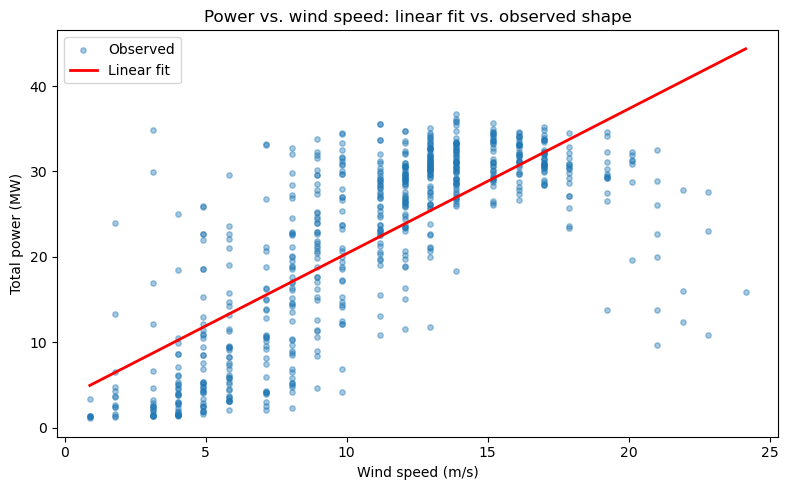

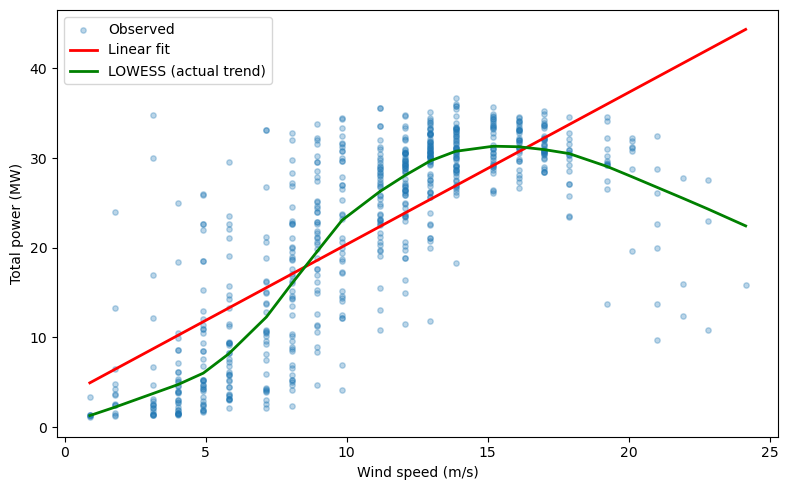

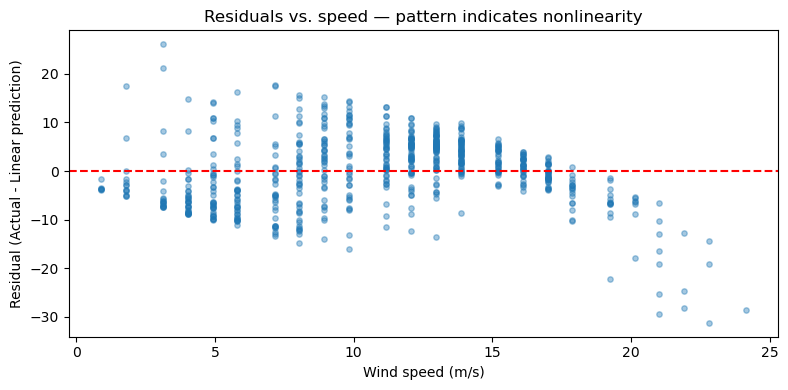

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

speed = np.sqrt(all_data['speed_u']**2 + all_data['speed_v']**2)
power = all_data['Total']

# fit a simple linear model: power ~ speed
lr = LinearRegression().fit(speed.values.reshape(-1, 1), power)
speed_range = np.linspace(speed.min(), speed.max(), 200)
pred_linear = lr.predict(speed_range.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(speed, power, alpha=0.4, s=15, label='Observed')
plt.plot(speed_range, pred_linear, color='red', linewidth=2, label='Linear fit')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Total power (MW)')
plt.title('Power vs. wind speed: linear fit vs. observed shape')
plt.legend()
plt.tight_layout()
plt.show()
from statsmodels.nonparametric.smoothers_lowess import lowess

smoothed = lowess(power, speed, frac=0.3)  # frac controls smoothness

plt.figure(figsize=(8, 5))
plt.scatter(speed, power, alpha=0.3, s=15, label='Observed')
plt.plot(speed_range, pred_linear, color='red', linewidth=2, label='Linear fit')
plt.plot(smoothed[:, 0], smoothed[:, 1], color='green', linewidth=2, label='LOWESS (actual trend)')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Total power (MW)')
plt.legend()
plt.tight_layout()
plt.show()

residuals = power - lr.predict(speed.values.reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.scatter(speed, residuals, alpha=0.4, s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Residual (Actual - Linear prediction)')
plt.title('Residuals vs. speed — pattern indicates nonlinearity')
plt.tight_layout()
plt.show()

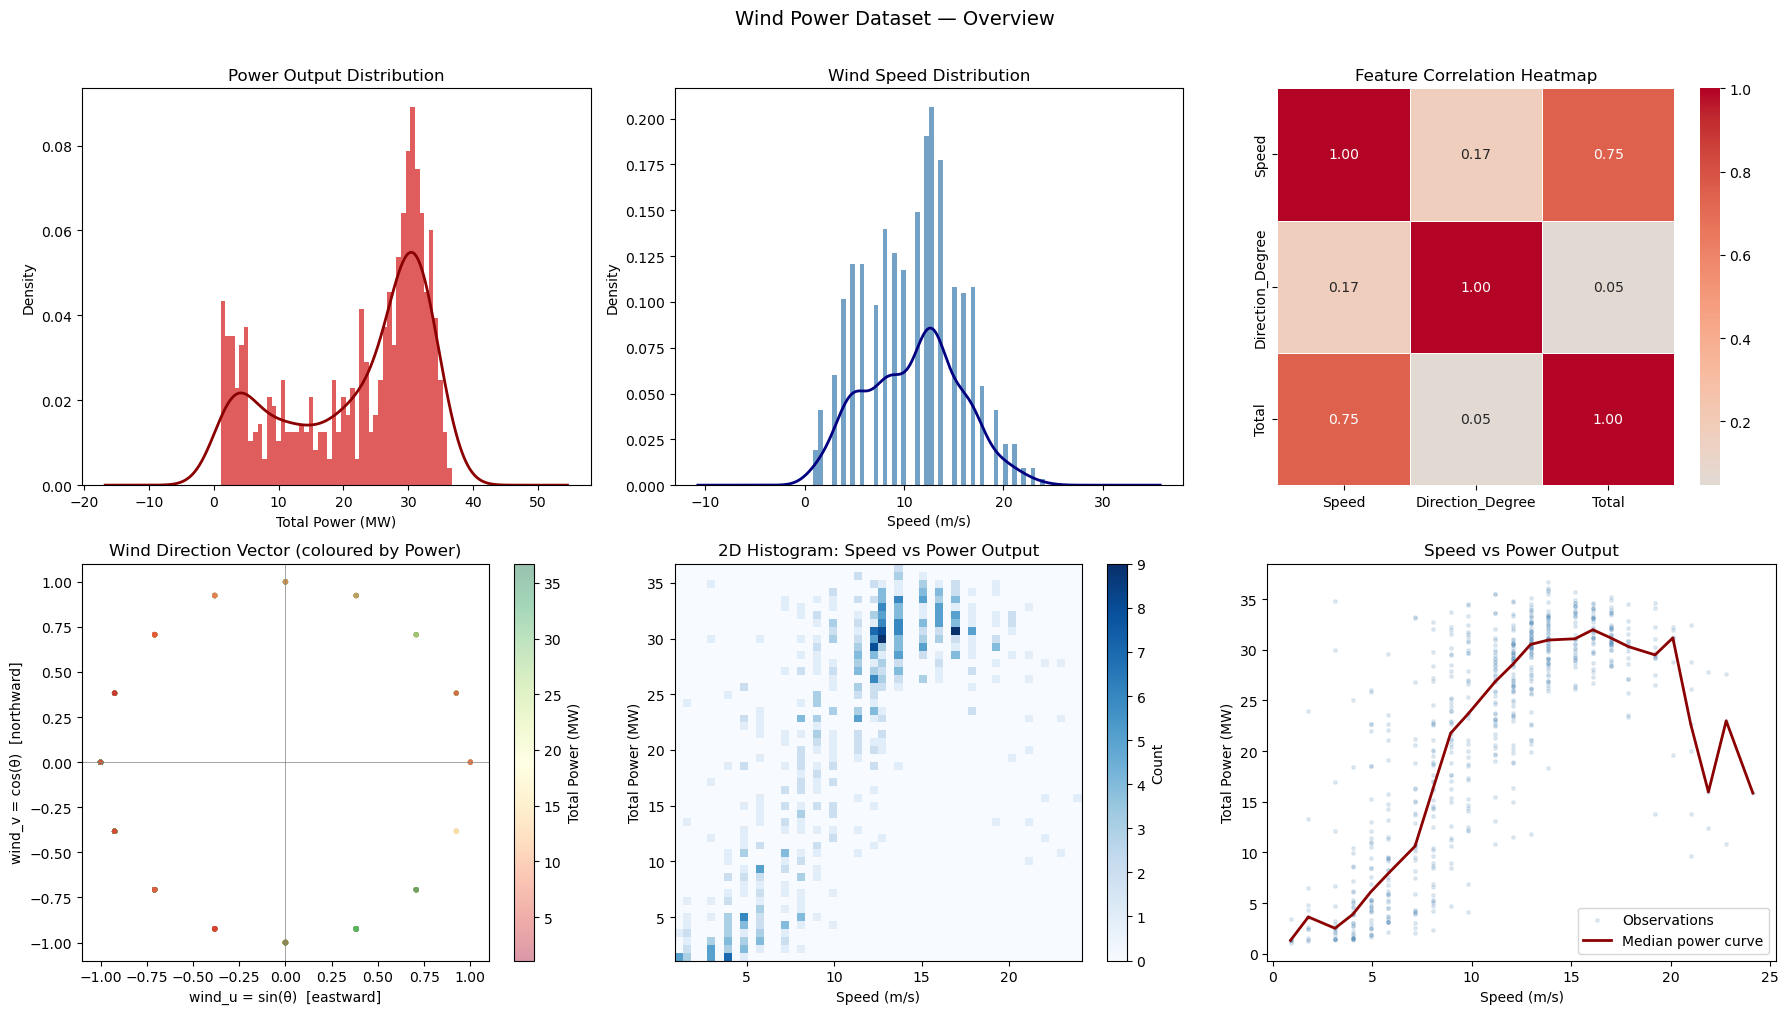

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 1. Power Output distribution ──────────────────────────────────────────────
axes[0, 0].hist(joined_dfs['Total'], bins=50, color='tab:red', alpha=0.75, density=True)
joined_dfs['Total'].plot.kde(ax=axes[0, 0], color='darkred', linewidth=2)
axes[0, 0].set_title('Power Output Distribution')
axes[0, 0].set_xlabel('Total Power (MW)')
axes[0, 0].set_ylabel('Density')

# ── 2. Wind Speed distribution ────────────────────────────────────────────────
axes[0, 1].hist(joined_dfs['Speed'], bins=50, color='steelblue', alpha=0.75, density=True)
joined_dfs['Speed'].plot.kde(ax=axes[0, 1], color='navy', linewidth=2)
axes[0, 1].set_title('Wind Speed Distribution')
axes[0, 1].set_xlabel('Speed (m/s)')
axes[0, 1].set_ylabel('Density')

# ── 3. Feature correlation heatmap ────────────────────────────────────────────
corr = joined_dfs[['Speed', 'Direction_Degree', 'Total']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0, 2], square=True)
axes[0, 2].set_title('Feature Correlation Heatmap')

# ── 4. Wind vector scatterplot (wind_u vs wind_v, coloured by power) ──────────
rad = np.deg2rad(joined_dfs['Direction_Degree'])
wind_u = np.sin(rad)
wind_v = np.cos(rad)

sc = axes[1, 0].scatter(wind_u, wind_v, c=joined_dfs['Total'],
                         cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[1, 0], label='Total Power (MW)')
axes[1, 0].set_title('Wind Direction Vector (coloured by Power)')
axes[1, 0].set_xlabel('wind_u = sin(θ)  [eastward]')
axes[1, 0].set_ylabel('wind_v = cos(θ)  [northward]')
axes[1, 0].axhline(0, color='grey', linewidth=0.5)
axes[1, 0].axvline(0, color='grey', linewidth=0.5)

# ── 5. 2D Histogram — Speed vs Power Output ───────────────────────────────────
h = axes[1, 1].hist2d(joined_dfs['Speed'], joined_dfs['Total'],
                       bins=50, cmap='Blues')
plt.colorbar(h[3], ax=axes[1, 1], label='Count')
axes[1, 1].set_title('2D Histogram: Speed vs Power Output')
axes[1, 1].set_xlabel('Speed (m/s)')
axes[1, 1].set_ylabel('Total Power (MW)')

# ── 6. Speed vs Power scatter (bonus: power curve overlay) ────────────────────
axes[1, 2].scatter(joined_dfs['Speed'], joined_dfs['Total'],
                   alpha=0.15, s=6, color='steelblue', label='Observations')
power_curve = joined_dfs.groupby('Speed')['Total'].median()
axes[1, 2].plot(power_curve.index, power_curve.values,
                color='darkred', linewidth=2, label='Median power curve')
axes[1, 2].set_title('Speed vs Power Output')
axes[1, 2].set_xlabel('Speed (m/s)')
axes[1, 2].set_ylabel('Total Power (MW)')
axes[1, 2].legend()

plt.suptitle('Wind Power Dataset — Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Evaluate your model

Now that you have a preprocessing pipeline ready, along with the final estimator, you may want to know how well your model performs. Choose the method you prefer, with special attention to the selected metric.

**Example**

In [65]:
# Split the data so we can test how well our model performs in unseen data
# X_train, X_test, y_train, y_test = train_test_split(X, y) # -> You might want to use another split method

# 80% train / 20% test — no shuffling, temporal order preserved
X = joined_dfs.drop(columns=['Total'])
y = joined_dfs['Total']

split_idx = int(len(joined_dfs) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


pipeline_lr.fit(X_train, y_train)
mae_lr = mean_absolute_error(pipeline_lr.predict(X_test), y_test)
print(f"LR  MAE: {mae_lr:.3f} MW")

pipeline_rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(pipeline_rf.predict(X_test), y_test)
print(f"RF  MAE: {mae_rf:.3f} MW")

pipeline_nn.fit(X_train, y_train)
mae_nn = mean_absolute_error(pipeline_nn.predict(X_test), y_test)
print(f"NN  MAE: {mae_nn:.3f} MW")


2026/08/12 03:30:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '194dca45586943a484428f2a61147de9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/12 03:30:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ea16c8bd91084ed6858159e36c600d41', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run amusing-asp-616 at: http://127.0.0.1:5000/#/experiments/5/runs/194dca45586943a484428f2a61147de9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
LR  MAE: 5.350 MW


2026/08/12 03:30:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e68d66cc61ba4b308819cb86550a67d4', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run gifted-dove-856 at: http://127.0.0.1:5000/#/experiments/5/runs/ea16c8bd91084ed6858159e36c600d41
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
RF  MAE: 3.687 MW
🏃 View run smiling-dog-191 at: http://127.0.0.1:5000/#/experiments/5/runs/e68d66cc61ba4b308819cb86550a67d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
NN  MAE: 3.650 MW


Let's see how our predictions look compared to the true values.

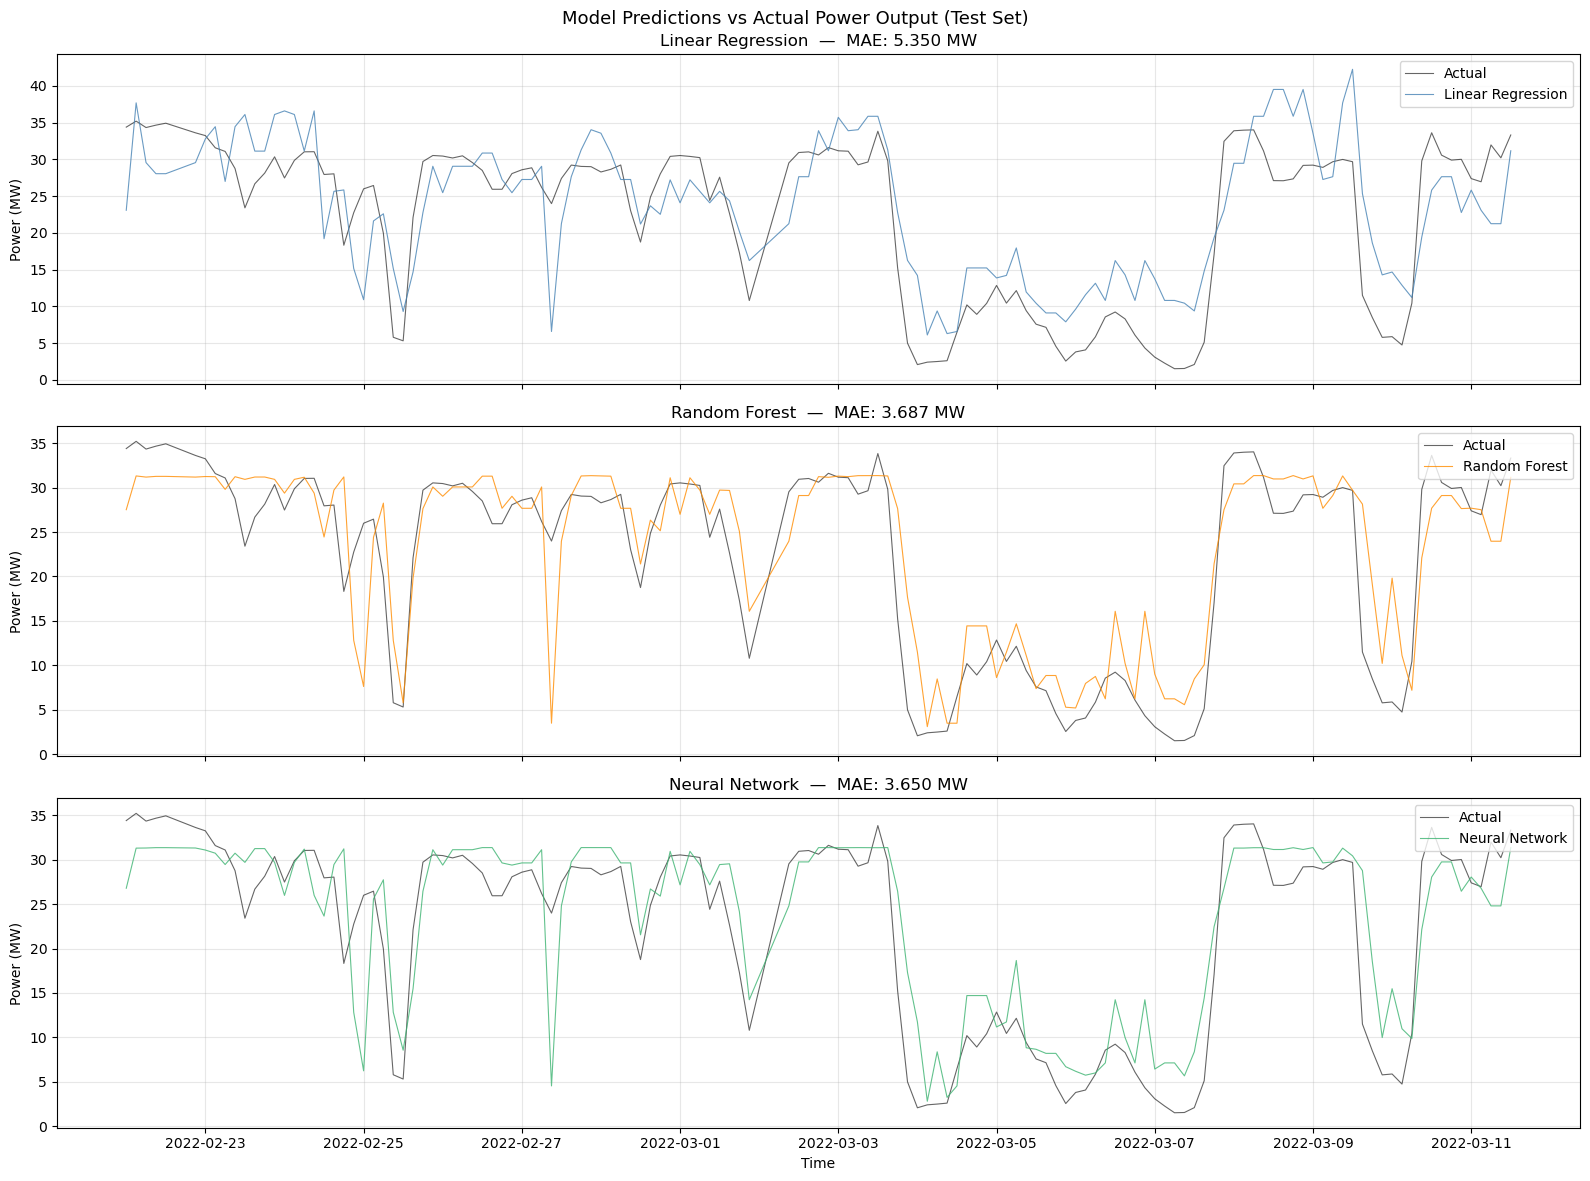

In [66]:
pred_lr = pipeline_lr.predict(X_test)
pred_rf = pipeline_rf.predict(X_test)
pred_nn = pipeline_nn.predict(X_test)

time_axis = X_test['time'].values

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

models = [
    ("Linear Regression", pred_lr, "steelblue"),
    ("Random Forest",     pred_rf, "darkorange"),
    ("Neural Network",    pred_nn, "mediumseagreen"),
]

for ax, (name, preds, color) in zip(axes, models):
    ax.plot(time_axis, y_test.values, color='black', linewidth=0.8,
            alpha=0.6, label='Actual')
    ax.plot(time_axis, preds, color=color, linewidth=0.8,
            alpha=0.8, label=name)
    mae = mean_absolute_error(y_test, preds)
    ax.set_title(f'{name}  —  MAE: {mae:.3f} MW')
    ax.set_ylabel('Power (MW)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time')
plt.suptitle('Model Predictions vs Actual Power Output (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()


HINT: Pay special attention to this type of data: We are dealing with Time series data (i.e. data that is recorded over consistent intervals of time). It might be a good idea not to randomly split the data, since it wouldn't respect the temporal order and may cause data-leakage, unintentionally inferring the trend of future samples.

In [77]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": pipeline_lr,
    "Random Forest":     pipeline_rf,
    "Neural Network":    pipeline_nn,
}

results = []
for name, pipeline in models.items():
    preds = pipeline.predict(X_test)
    results.append({
        "Model": name,
        "MAE":   mean_absolute_error(y_test, preds),
        "RMSE":  np.sqrt(mean_squared_error(y_test, preds)),
        "R²":    r2_score(y_test, preds),
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.round(4)
print(results_df)


                    MAE  RMSE    R²
Model                              
Linear Regression 5.350 6.409 0.653
Random Forest     3.706 5.230 0.769
Neural Network    3.803 5.204 0.772


## Tracking your experiments with MLFlow
We have a working model with a certain accuracy. But wouldn't it be better to try different parameters and different models before deciding for one?

This is exactly what we will do using the MLFlow library. MLflow is an open source platform to manage the ML lifecycle, including experimentation, reproducibility, deployment, and a central model registry. This will allow us for easy comparison of all our model experiments.

Example
When using MLFlow locally to log our experiments, we need to start a "local server". We can do this easily by running the following in our command line interface (in the Terminal):

```
mlflow server --host 127.0.0.1 --port 5000
```

Once you start the server you will see the following information in the Terminal: `Uvicorn running on http://127.0.0.1:5000`.

The server is located at our localhost `127.0.0.1, port 5000`. We will use this information to indicate where our experiment logs will be shown.

In [ ]:
# # Start an MLflow                    
# mlflow.sklearn.autolog() # This is to help us track scikit learn metrics.
# mlflow.set_tracking_uri("http://127.0.0.1:5000") # We set the MLFlow UI to display in our local host.

# # Set the experiment and run name
# experiment_name = "LinearRegression-Example" # Think how to best organise experiments - for example by model type
# run_name = "Simple_regression" # Give explicit names 

# mlflow.set_experiment(experiment_name)

# with mlflow.start_run(run_name=run_name) as run:
    
#     # Train our model
#     pipeline_example.fit(X_train, y_train)

#     # Evaluate the model, using MAE as a metric
#     pred_nn = pipeline_nn.predict(X_test)
#     metrics_dict = {
#         "mae" : mean_absolute_error(pred_nn, y_test),
#         'R': r2_score(y_test, pred_nn),
#         'RMSE': np.sqrt(mean_squared_error(y_test, pred_nn))
#     }

#     mlflow.log_metric(metrics_dict)

🏃 View run Simple_regression at: http://127.0.0.1:5000/#/experiments/1/runs/94f35b4ef0854461acbf6e2958636160
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


TypeError: float() argument must be a string or a real number, not 'Timestamp'

In the example above you can see that:
- we are using `sklearn.autolog()` to automatically log `scikit-learn` specific metrics
- we set an experiment_name; if the experiment doesn't exist it will create a new one, otherwise it will use the already existent experiment
- we set a run_name; same as above
- after model training we record the MAE to compare between runs

Click on either of the links above to see your experiments. Have a look at the Overview, Model metrics, and Artifacts.

Now have a look at the *Explorer* tab on the left and notice the newly created files and folders: 
- `mlflow.db` - a database containing metadata regarding experiments, runs, and parameters that you logged
- `mlartifacts/` folders
    - each folder will correspond to a run
    - the `models` folder contains data about the logged models, such as the envinroment file, a .pkl file containing the model, and a MLmodel complete description of the model; have a look at each of those

Now try out different set-ups. You can experiment with different pre-processing steps, models, and parameters. If you need a tutorial on MLflow Tracking you can find one [here](https://mlflow.org/docs/latest/ml/tracking/).

In [68]:
#run: mlflow server --host 127.0.0.1 --port 5000     

from mlflow.models import infer_signature

mlflow.sklearn.autolog(log_models=False)
mlflow.set_tracking_uri("http://127.0.0.1:5000")

experiments = [
    ("WindPower-LinearRegression", "LR_run", "WindPower-LR", pipeline_lr),
    ("WindPower-RandomForest",     "RF_run", "WindPower-RF", pipeline_rf),
    ("WindPower-NeuralNetwork",    "NN_run", "WindPower-NN", pipeline_nn),
]

# Minimal input — only what the pipeline actually requires
X_train_minimal = X_train[['time', 'Speed', 'Direction']]

for experiment_name, run_name, model_name, pipeline in experiments:
    mlflow.set_experiment(experiment_name)
    with mlflow.start_run(run_name=run_name):
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)

        mlflow.log_metric("MAE",  mean_absolute_error(y_test, preds))
        mlflow.log_metric("RMSE", np.sqrt(mean_squared_error(y_test, preds)))
        mlflow.log_metric("R2",   r2_score(y_test, preds))

        signature = infer_signature(X_train_minimal, preds)  # <-- fixed
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model",
            signature=signature,
            registered_model_name=model_name,
        )



2026/08/12 03:30:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 03:30:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'WindPower-LR' already exists. Creating a new version of this model...
2026/08/12 03:31:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WindPower-LR, version 4
Created version '4' of model 'WindPower-LR'.


🏃 View run LR_run at: http://127.0.0.1:5000/#/experiments/1/runs/c669096c8cbc4817a19b0b2979d67e44
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/08/12 03:31:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 03:31:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'WindPower-RF' already exists. Creating a new version of this model...
2026/08/12 03:31:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WindPower-RF, version 4
Created version '4' of model 'WindPower-RF'.


🏃 View run RF_run at: http://127.0.0.1:5000/#/experiments/2/runs/446e6ef14d734304901f1517b29906a2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


2026/08/12 03:31:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 03:31:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'WindPower-NN' already exists. Creating a new version of this model...
2026/08/12 03:31:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WindPower-NN, version 4


🏃 View run NN_run at: http://127.0.0.1:5000/#/experiments/3/runs/3564de639a8d4a65ab990e30e4698f5c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '4' of model 'WindPower-NN'.


### Comparing models

Suppose you have ran some experiments, trying different pre-processing steps, models, and parameters. To easily compare the results from our experiments, we can use the MLFlow interface.

**Example.**
We have been logging our experiments in our local server. We can access the UI by opening the localhost address in any browser. You should see a list of all the experiments under *Experiments*. When logging multiple runs with different parameters/metrics, you will be able to easily compare them using the "Chart View". Make sure to try this out.

## Registering the best model

Now suppose you have tried many different models with different parameters, you might want to register the best one. To do this, we can use again the UI. You can follow the instructions below or this [visual guide](register_model_guide.pdf) which you can open in the repository:

- In the Experiments list, select the name of the experiment you want. 
- Click Models in the left panel.
- Click on the model you want to use, in this case it's named "model"
- Then "Register Model".
- First "Select a model", click "Create New Model" and name it "LinearRegression"

Now, if you go to the Homepage, on the "Models" tab, you will see that you registered the model.

In case of doubt, you can check the [documentation](https://mlflow.org/docs/latest/ml/model-registry/tutorial/).

**Using a registered model**

Now that we have registered our best model, we can use it for future predictions. We can retrieve the weather forecasts for the next days, and make predictions of power generation.

**Example.**
First we need the new forecast data:

In [78]:
future_df = pd.read_csv("data/future.csv")
future_df["time"] = pd.to_datetime(future_df["time"], utc=True)
future_df = future_df[['time', 'Speed', 'Direction']]
future_df

,time,Speed,Direction
0,2022-03-11 15:00:00+00:00,15.199,SE
1,2022-03-11 18:00:00+00:00,16.093,SE
2,2022-03-11 21:00:00+00:00,16.988,SE
3,2022-03-12 00:00:00+00:00,16.093,SSE
4,2022-03-12 03:00:00+00:00,12.964,SSE
5,2022-03-12 06:00:00+00:00,8.047,SSE
6,2022-03-12 09:00:00+00:00,8.941,SSE
7,2022-03-12 12:00:00+00:00,11.176,SE
8,2022-03-12 15:00:00+00:00,12.070,SSE
9,2022-03-12 18:00:00+00:00,8.941,SSW


Then, we can retrieve any saved model and use it to predict on the new data:

In [79]:
model_name = "RandomForest"  
model_version = 1

model_uri = f"models:/{model_name}/{model_version}"
model = mlflow.pyfunc.load_model(model_uri=model_uri)

future_df_pred = future_df.copy()
future_df_pred['time'] = future_df_pred['time'].dt.tz_convert('UTC').dt.tz_localize(None)

predictions = model.predict(future_df_pred)

predictions_df = future_df[['time', 'Speed', 'Direction']].copy()
predictions_df['Predicted_Power_MW'] = predictions
print(predictions_df)

predictions_df = future_df[["time", "Speed", "Direction"]].copy()
predictions_df["Predicted_Power_MW"] = predictions
print(predictions_df)



                        time  Speed Direction  Predicted_Power_MW
0  2022-03-11 15:00:00+00:00 15.199        SE              30.983
1  2022-03-11 18:00:00+00:00 16.093        SE              31.188
2  2022-03-11 21:00:00+00:00 16.988        SE              31.188
3  2022-03-12 00:00:00+00:00 16.093       SSE              31.335
4  2022-03-12 03:00:00+00:00 12.964       SSE              30.612
5  2022-03-12 06:00:00+00:00  8.047       SSE              23.037
6  2022-03-12 09:00:00+00:00  8.941       SSE              24.193
7  2022-03-12 12:00:00+00:00 11.176        SE              25.993
8  2022-03-12 15:00:00+00:00 12.070       SSE              29.129
9  2022-03-12 18:00:00+00:00  8.941       SSW              23.364
10 2022-03-12 21:00:00+00:00  5.812         S              20.373
11 2022-03-13 00:00:00+00:00  8.047       SSE              23.037
12 2022-03-13 03:00:00+00:00  9.835        SE              23.862
13 2022-03-13 06:00:00+00:00 12.964        SE              30.097
14 2022-03

In [53]:
from itertools import product
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("MLPRegressor-GridSearch")

# Parameter grid
param_grid = {
    "hidden_layer_sizes": [(32,), (64, 32), (128, 64, 32)],
    "activation":         ["relu", "tanh"],
    "alpha":              [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01],
}

tscv = TimeSeriesSplit(n_splits=5)

best_mae   = float("inf")
best_params = {}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Running {len(combos)} combinations × {tscv.n_splits} folds …\n")

for combo in combos:
    params = dict(zip(keys, combo))
    fold_maes = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(joined_dfs)):
        X_tr = joined_dfs.iloc[train_idx]
        y_tr = joined_dfs["Total"].iloc[train_idx]
        X_va = joined_dfs.iloc[val_idx]
        y_va = joined_dfs["Total"].iloc[val_idx]

        pipe = Pipeline(_preprocessing + [
            ("model", MLPRegressor(
                **params,
                max_iter=500,
                early_stopping=True,
                random_state=42,
            ))
        ])
        pipe.fit(X_tr, y_tr)
        fold_maes.append(mean_absolute_error(pipe.predict(X_va), y_va))

    cv_mae = float(np.mean(fold_maes))

    run_name = (
        f"MLP_layers={'x'.join(str(n) for n in params['hidden_layer_sizes'])}"
        f"_act={params['activation']}"
        f"_alpha={params['alpha']}"
        f"_lr={params['learning_rate_init']}"
    )

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metric("cv_mae", cv_mae)
        mlflow.log_param("n_splits", tscv.n_splits)

    print(f"  {run_name:80s}  cv_mae={cv_mae:.4f} MW")

    if cv_mae < best_mae:
        best_mae    = cv_mae
        best_params = params

print(f"\nBest cv_mae: {best_mae:.4f} MW")
print(f"Best params: {best_params}")


2026/08/12 03:07:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c321406bcbe3494893d7ccb91bde0efc', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Running 24 combinations × 5 folds …



c:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/08/12 03:07:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c3229ab0ffdc4ffe9bafa9404ffb2e43', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run nosy-stoat-521 at: http://127.0.0.1:5000/#/experiments/4/runs/c321406bcbe3494893d7ccb91bde0efc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


c:\Users\User\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/08/12 03:07:18 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0ac4c0ab4d2e4874b288cdfd188474e9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


...

🏃 View run melodic-carp-841 at: http://127.0.0.1:5000/#/experiments/4/runs/5965eebcba624a6aac0365b74f8cfb24
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


2026/08/12 03:09:21 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd89ee150a9ba493c87e26798e791540b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run angry-goose-998 at: http://127.0.0.1:5000/#/experiments/4/runs/5e2a2673b4434a08b7c51d721bb7a3d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


2026/08/12 03:09:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c75e2935482948f1ae1ae2620096c0a1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run mercurial-quail-211 at: http://127.0.0.1:5000/#/experiments/4/runs/d89ee150a9ba493c87e26798e791540b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
🏃 View run serious-cat-529 at: http://127.0.0.1:5000/#/experiments/4/runs/c75e2935482948f1ae1ae2620096c0a1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
🏃 View run MLP_layers=128x64x32_act=tanh_alpha=0.001_lr=0.01 at: http://127.0.0.1:5000/#/experiments/4/runs/e9f69cc847cf4ab9864eda6bf4c21c3f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
  MLP_layers=128x64x32_act=tanh_alpha=0.001_lr=0.01                                 cv_mae=6.9598 MW

Best cv_mae: 5.0035 MW
Best params: {'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'alpha': 0.001, 'learning_rate_init': 0.01}


In [54]:
from itertools import product
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("RandomForestRegressor-GridSearch")

# Parameter grid
param_grid = {
    "n_estimators":     [100, 300, 500],
    "max_depth":        [5, 8, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features":     ["sqrt", 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

best_mae    = float("inf")
best_params = {}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Running {len(combos)} combinations × {tscv.n_splits} folds …\n")

for combo in combos:
    params = dict(zip(keys, combo))
    fold_maes = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(joined_dfs)):
        X_tr = joined_dfs.iloc[train_idx]
        y_tr = joined_dfs["Total"].iloc[train_idx]
        X_va = joined_dfs.iloc[val_idx]
        y_va = joined_dfs["Total"].iloc[val_idx]

        pipe = Pipeline(_preprocessing + [
            ("model", RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1,
            ))
        ])
        pipe.fit(X_tr, y_tr)
        fold_maes.append(mean_absolute_error(pipe.predict(X_va), y_va))

    cv_mae = float(np.mean(fold_maes))

    run_name = (
        f"RF_n={params['n_estimators']}"
        f"_depth={params['max_depth']}"
        f"_leaf={params['min_samples_leaf']}"
        f"_feat={params['max_features']}"
    )

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metric("cv_mae", cv_mae)
        mlflow.log_param("n_splits", tscv.n_splits)

    print(f"  {run_name:80s}  cv_mae={cv_mae:.4f} MW")

    if cv_mae < best_mae:
        best_mae    = cv_mae
        best_params = params

print(f"\nBest cv_mae: {best_mae:.4f} MW")
print(f"Best params: {best_params}")

2026/08/12 03:10:57 INFO mlflow.tracking.fluent: Experiment with name 'RandomForestRegressor-GridSearch' does not exist. Creating a new experiment.
2026/08/12 03:10:57 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9cd01bf23f674efd971d24605873ff5e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Running 54 combinations × 5 folds …



2026/08/12 03:10:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '490bdb11ab4d4790b10e99fddef62057', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run angry-conch-941 at: http://127.0.0.1:5000/#/experiments/5/runs/9cd01bf23f674efd971d24605873ff5e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/08/12 03:10:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f1119741664e4f68add319f3851170e1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


...

🏃 View run receptive-ox-414 at: http://127.0.0.1:5000/#/experiments/5/runs/7e1f3dd333da44a7a21572693fec20b3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/08/12 03:15:56 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5367d232da754686922ece10b64ecba5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run auspicious-shrew-412 at: http://127.0.0.1:5000/#/experiments/5/runs/5367d232da754686922ece10b64ecba5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/08/12 03:15:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '30db383069ad4a8fab0b88aee44738d7', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run sincere-fly-964 at: http://127.0.0.1:5000/#/experiments/5/runs/30db383069ad4a8fab0b88aee44738d7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
🏃 View run RF_n=500_depth=None_leaf=10_feat=1.0 at: http://127.0.0.1:5000/#/experiments/5/runs/3f28dffab2ae4aa3ab57742bb522b40f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
  RF_n=500_depth=None_leaf=10_feat=1.0                                              cv_mae=4.4474 MW

Best cv_mae: 4.4150 MW
Best params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 1.0}


## Serving your model

So far, we have trained several models and registered the best one. Often times, we will want to deploy the best model in such a way that other people can take advantage of it, by sending a request with data and getting back predictions. In this project you will only serve the model locally, a step usually done before deployment to ensure that the model works as expected. 

Serving a model refers to the process of making a trained machine learning model available to receive input data and provide predictions or inferences based on that data. In other words, when you serve a model, you set it up in a way that it can be queried with new data, and it will produce predictions or outputs based on the patterns it learned during training.

Serving a model is a critical step in the machine learning lifecycle, as it allows you to leverage the model's predictive capabilities in real-world applications. When a model is served, it becomes accessible to applications, websites, or other systems that need to utilize its predictions.

You have tried serving the model in [one of the previous exercises](https://github.com/LSDA-BDM/exercise-mlflow-caiso). Run the same command to serve your current model.

> Note. The current configuration is slightly different that in the exercise. You won't have to call `mlflow run .` as in the exercise. Do you know why? However, before serving the model, you will have to set the tracking URI in the terminal with:
> ```bash
> export MLFLOW_TRACKING_URI=http://localhost:5000
> ```

Serve the model and then use `curl` to test that it worked.

## Packaging your project

Lastly, we want to make sure that others are able to run the project and do further development. As opposed to just making the model available as before (with serving) now you will package the project in order to make it reproducible.

Reproducibility refers to the ability of researchers, developers, and practitioners to recreate the exact same results, analyses, and outcomes from a given set of source code and data. In that sense, MLflow Projects is a standardized way to encapsulate an experiment in a reproducible
manner, so colleagues or other stakeholders can reproduce your code. This is done by specifying all the dependencies using a 'pip' environment file, a 'conda' environment file, or a docker environment. Here we will take the ‘pip‘ approach.

An MLflow project consists (at least) of:

- The code you want to package, including the data for your experiments (if needed). Jupyter Notebooks are not supported, so you will have to more the relevant code in `.py` file; you can check the `script.py` file provided for an example.
- A requirements.txt file specifying the dependencies for the code (in this case a text file with ‘pip‘-installable dependencies).
- An MLproject file specifying which environment file to use, parameters accepted, and the entry points to the code.

First, try to run the script `script.py` with

```bash
python script.py
```
> Note: For this to run you must have started an mlflow server as shown in Tracking your experiments.

Then, create a similar script containing your experiments; also create the other files necessary for an MLProject. Have a look at [this exercise](https://github.com/LSDA-BDM/exercise-polynomial/) that explains how MLflow projects work.

## Notes and hints

Here are a few resources you can use to inform your design decisions for your experiments:

**Joining the data.** How do you join and align the data will affect the amount of data you end up with for training your model. Make sure you explain your decision and reflect upon its pros and cons. Some resources for pandas: [Join](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html), [Merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html), [Resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html).

**Wind direction encoding.** You will most likely need to transform the wind direction into a numerical feature. Some possibilities to consider, make sure you reflect on their advantages and disadvantages:
- [OneHotEncoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- Transforming to degrees or radians with a [custom transformer](https://towardsdatascience.com/pipelines-custom-transformers-in-scikit-learn-ef792bbb3260/)
- Converting speed and direction to a [2-dimensional vector](https://www.tensorflow.org/tutorials/structured_data/time_series#wind)

**Scaling.** Think what is the range of your features. Is your model affected by this? Should you scale your features? You should explain why would you do it, or why it's not necessary. Check [Scikit-Learn's Preprocessing and Normalization](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling) or this [article](https://www.geeksforgeeks.org/ml-feature-scaling-part-2/).

**Feature transformations.** If you want to apply different transformations to different columns (e.g. categorical and numerical), you can use the [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

**Missing values.** Check [Scikit-Learn’s imputers](https://scikit-learn.org/stable/modules/impute.html) to see different options for dealing with missing values. 

**Splitting and shuffling.** You are working with time series data. Is it acceptable to do a random shuffle on the data when splitting for training? If so, why? If not, how can you split the data? Make sure to argue your decision. Check [Scikit-Learn’s TimeSeries Split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#sklearn.model_selection.TimeSeriesSplit) or this [article](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).